# Blood Pressure Logistic Regression

## Load modules

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

print("NumPy Version :{}".format(np.__version__))
print("TensorFlow Version :{}".format(tf.__version__))
print("Matplotlib Version :{}".format(plt.matplotlib.__version__))

NumPy Version :2.0.2
TensorFlow Version :2.19.0
Matplotlib Version :3.10.0


## Input and Label

In [2]:
#Input(AGE, BMI) and Labels(BP)
x_input = tf.constant([[25,22],[25,26],[25,30],[35,22],[35,26],[35,30],[45,22],[45,26],[45,30],[55,22],[55,26],[55,30],[65,22],[65,26],[65,30],[73,22],[73,26],[73,30]], dtype= tf.float32)
labels = tf.constant([[0],[0],[1],[0],[1],[0],[0],[0],[1],[0],[0],[1],[1],[1],[1],[0],[1],[1]], dtype= tf.float32)

## Min Max Scaler

In [3]:
x_input_org = x_input
x_min, x_max = np.min(x_input, axis=0), np.max(x_input, axis=0)
x_input = (x_input-x_min)/(x_max-x_min)

## Model 정의

In [4]:
model = tf.keras.models.Sequential([
  tf.keras.Input(shape=(2,)),
  tf.keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

## Model compile

In [5]:
model.compile(optimizer= tf.keras.optimizers.SGD(learning_rate=0.1), loss='binary_crossentropy', metrics=['accuracy'])

## 학습 (Training)

In [ ]:
%%time
history = model.fit(x_input, labels, epochs=1000)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 576ms/step - accuracy: 0.5556 - loss: 0.6566
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5556 - loss: 0.6518
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5556 - loss: 0.6473
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5556 - loss: 0.6430
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5556 - loss: 0.6390
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5556 - loss: 0.6352
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5556 - loss: 0.6315
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5556 - loss: 0.6281
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6111 - loss: 0.6248
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6111 - loss: 0.6217
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.6111 - loss: 0.6188
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy

### Plot

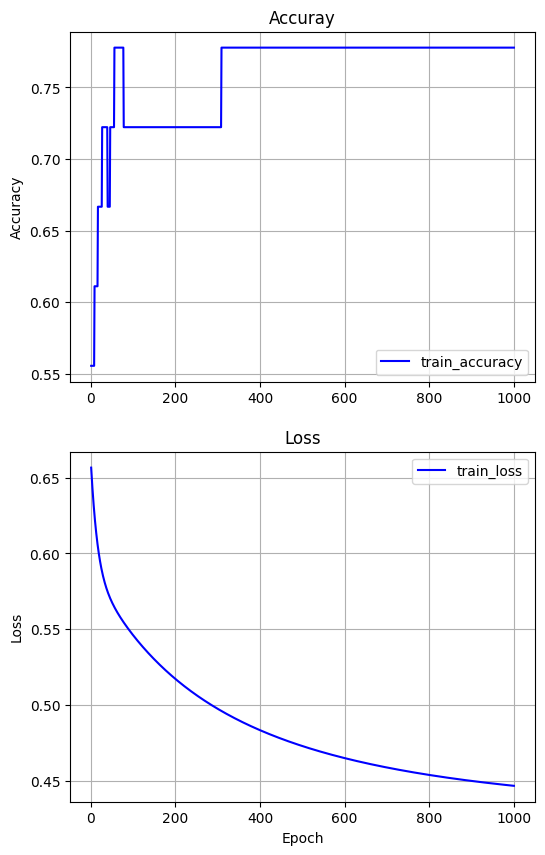

In [ ]:
# accuray, loss 그래프 출력
loss = history.history['loss']
epochs = range(1, len(loss)+1)

plt.figure(figsize=(6, 10))
plt.subplot(2, 1, 1)
plt.title('Accuray')
plt.plot(epochs, history.history['accuracy'], 'b', label='train_accuracy')
plt.grid(True)
plt.ylabel('Accuracy')
plt.legend(loc='best')

plt.subplot(2, 1, 2)
plt.title('Loss')
plt.plot(epochs, history.history['loss'], 'b', label='train_loss')
plt.grid(True)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='best')
plt.show()

## Training 결과 Test

In [ ]:
H_x = model.predict(x_input)
for x,h,l in zip(x_input_org, H_x, labels):
  print("Age:{}, BMI:{:>7.4} => Result:{:>7.4} [label => {}]".format(x[0],x[1],h[0],l))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Age:25.0, BMI:   22.0 => Result:0.07072 [label => [0.]]
Age:25.0, BMI:   26.0 => Result: 0.2545 [label => [0.]]
Age:25.0, BMI:   30.0 => Result:  0.605 [label => [1.]]
Age:35.0, BMI:   22.0 => Result: 0.1075 [label => [0.]]
Age:35.0, BMI:   26.0 => Result: 0.3508 [label => [1.]]
Age:35.0, BMI:   30.0 => Result:  0.708 [label => [0.]]
Age:45.0, BMI:   22.0 => Result: 0.1601 [label => [0.]]
Age:45.0, BMI:   26.0 => Result:  0.461 [label => [0.]]
Age:45.0, BMI:   30.0 => Result: 0.7933 [label => [1.]]
Age:55.0, BMI:   22.0 => Result: 0.2318 [label => [0.]]
Age:55.0, BMI:   26.0 => Result: 0.5751 [label => [0.]]
Age:55.0, BMI:   30.0 => Result: 0.8586 [label => [1.]]
Age:65.0, BMI:   22.0 => Result: 0.3232 [label => [1.]]
Age:65.0, BMI:   26.0 => Result: 0.6818 [label => [1.]]
Age:65.0, BMI:   30.0 => Result: 0.9058 [label => [1.]]
Age:73.0, BMI:   22.0 => Result: 0.4081 [label => [0.]]
Age:73.0, BMI:   26.0 => Result: 0.7557 [label => [1.]]
Age:73.0, 

## Predict

In [ ]:
def predict(x):
  return model.predict((x-x_min)/(x_max-x_min))

In [ ]:
x_test = tf.constant([[50.0, 25.0]], dtype= tf.float32)
H_x = predict(x_test)
print("Age : {}, BMI : {} => Result : {:>7.4}".format(x_test[0,0],x_test[0,1],H_x[0,0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Age : 50.0, BMI : 25.0 => Result :  0.4251
